# **Proyecto Aplicado: Predicción No Lineal de Resolución de Quejas Financieras (CFPB)**

**Autor:** William Alejandro Moncada Cifuentes - Noel Eduardo Perez Barrios - Edgar Julian Mendez Ortegon

**Asignatura:** Aprendizaje Máquina II

**Dataset:** Consumer Financial Protection Bureau (CFPB) — ~73,600 quejas financieras

**Fecha:** Mayo 2026

##  Identificación del Contexto y Caso de Uso

**Problema Real:** Las instituciones financieras reciben miles de quejas diarias. Determinar qué quejas escalarán hasta requerir un "alivio" (compensación monetaria o ajuste) frente a las que solo requieren una "explicación" es un proceso costoso y manual.

**Relevancia:** Automatizar este triaje inicial mediante inteligencia artificial permite a los bancos priorizar los casos críticos, reducir tiempos de respuesta y evitar multas regulatorias.

**Justificación de No Linealidad:** La relación entre el texto de una queja y su resolución no es lineal. Por ejemplo, una queja muy larga no garantiza compensación, ni tampoco una queja con sentimiento muy negativo (vader_neg). Es la interacción compleja y multidimensional (ej. sentimiento negativo + alta densidad de términos legales + mención de entidades específicas) lo que determina el resultado. Los modelos lineales (como la regresión logística) fracasan al intentar modelar esto, haciendo necesarios los Métodos de Kernel.

## Diseño de la Ruta de Ejecución del Proyecto

**Objetivo General:** Desarrollar un modelo de aprendizaje automático basado en métodos de kernel capaz de clasificar la resolución de una queja financiera (Alivio vs. Explicación) utilizando métricas extraídas del procesamiento de lenguaje natural (NLP).

**Enfoque Técnico:** Problema de Clasificación Binaria con manejo de desbalanceo de clases.

## Fases del Proyecto:

**Ingesta y Selección:** Carga de dataset y filtrado exclusivo de las 18 variables numéricas derivadas del NLP.

**Análisis Exploratorio (EDA) No Lineal:** Visualización de la separabilidad de las clases utilizando técnicas de reducción de dimensionalidad (como t-SNE o PCA) para demostrar que un hiperplano lineal no es suficiente.

**Adaptación y Submuestreo:** Aplicación de un submuestreo estratificado para que el algoritmo de Kernel pueda procesar los datos en tiempos académicos.

**Modelado y Optimización:** Entrenamiento de un Support Vector Classifier (SVC) con un Kernel Gaussiano (RBF) y búsqueda de hiperparámetros (C y gamma) usando validación cruzada.

**Evaluación:** Comparación frente a métricas objetivas (F1-Score, ROC-AUC).


### Fase 1: Ingesta de Datos y Análisis Exploratorio (EDA)

En esta primera etapa, cargaremos el dataset procesado que contiene métricas de Procesamiento de Lenguaje Natural (NLP). El objetivo de esta fase es estructurar la variable objetivo (Alivio vs. Explicación) y demostrar visualmente por qué las características del texto presentan una separabilidad no lineal, justificando así el uso de métodos de kernel (SVM con Kernel RBF) en fases posteriores.

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

# Configuración visual para gráficas de alta calidad
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
warnings.filterwarnings("ignore")

print("✓ Librerías cargadas con éxito para la Fase 1.")

✓ Librerías cargadas con éxito para la Fase 1.


In [2]:
# 2. CARGA DE DATOS Y CREACIÓN DEL TARGET BINARIO
DATA_PATH = "04_features.csv" 
df = pd.read_csv(DATA_PATH)

# Función para clasificar el target
def classify_relief(response):
    if pd.isna(response): 
        return np.nan
    response = str(response).strip().lower()
    if "monetary relief" in response or "non-monetary relief" in response: 
        return 1 # Favorable para el consumidor
    elif "explanation" in response: 
        return 0 # Solo explicación
    else: 
        return np.nan

# Aplicar la clasificación y limpiar nulos en el target
df["target_relief"] = df["Company response to consumer"].apply(classify_relief)
df_ml = df.dropna(subset=["target_relief"]).copy()
df_ml["target_relief"] = df_ml["target_relief"].astype(int)

# Seleccionar exclusivamente nuestras variables predictoras (Features numéricas de NLP)
nlp_features = [
    "narrative_length", "word_count", "unique_words", "lexical_diversity",
    "legal_term_count", "uppercase_ratio", "mask_count",
    "entity_count", "org_count", "law_count", "money_count", "gpe_count",
    "vader_compound", "vader_neg", "vader_neu", "vader_pos", 
    "textblob_polarity", "textblob_subjectivity"
]

# Filtrar el dataset final para ML (asegurando que no haya nulos en las features)
df_ml = df_ml.dropna(subset=nlp_features)
X = df_ml[nlp_features]
y = df_ml["target_relief"]

print(f"Dataset estructurado con éxito.")
print(f"Total de registros a analizar: {X.shape[0]}")
print(f"Total de características de NLP (Features): {X.shape[1]}\n")

# Mostrar la proporción real del desbalance
print("Distribución de la Variable Objetivo:")
print(y.value_counts(normalize=True).round(3) * 100)

Dataset estructurado con éxito.
Total de registros a analizar: 73343
Total de características de NLP (Features): 18

Distribución de la Variable Objetivo:
target_relief
0    66.4
1    33.6
Name: proportion, dtype: float64


#### Análisis Exploratorio (EDA) - Justificación de No Linealidad

Para justificar el uso de métodos avanzados (Kernel), primero debemos entender cómo interactúan nuestras variables.
A continuación, visualizaremos la relación entre el Sentimiento del Texto (`vader_compound`) y la Densidad de Términos Legales (`legal_term_count`). Si un modelo lineal fuera suficiente, veríamos una división clara (una línea recta) que separa los puntos de "Alivio" y "Explicación".

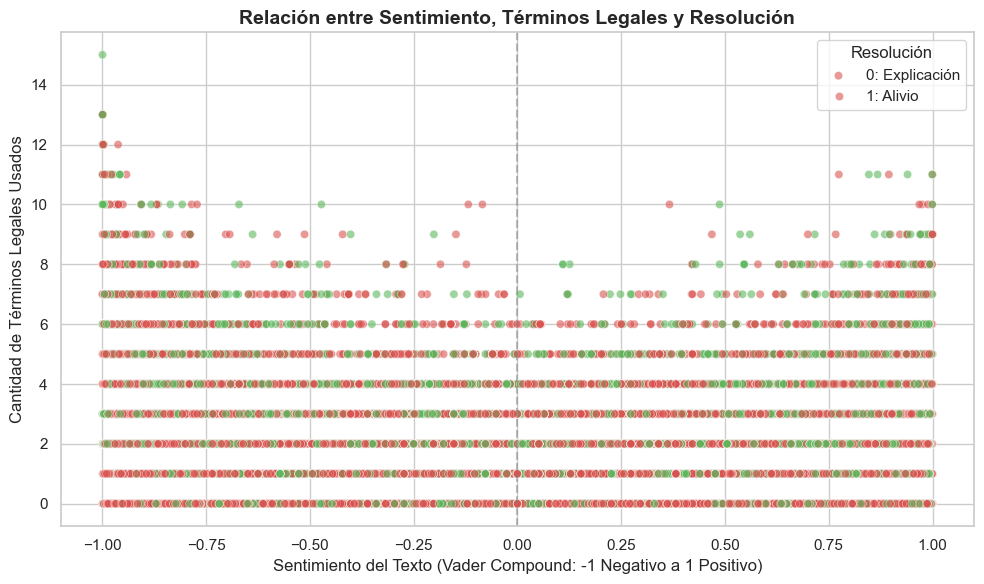

In [6]:
# 3. VISUALIZACIÓN BIVARIADA: Búsqueda de fronteras lineales
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml, 
    x='vader_compound', 
    y='legal_term_count', 
    hue='target_relief', 
    palette={0: '#d9534f', 1: '#5cb85c'}, # Rojo para explicación, Verde para alivio
    alpha=0.6
)

plt.title('Relación entre Sentimiento, Términos Legales y Resolución', fontsize=14, fontweight='bold')
plt.xlabel('Sentimiento del Texto (Vader Compound: -1 Negativo a 1 Positivo)')
plt.ylabel('Cantidad de Términos Legales Usados')
plt.legend(title='Resolución', labels=['0: Explicación', '1: Alivio'])
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


***Observación:** Como se aprecia en el gráfico, los puntos verdes (Alivio) y rojos (Explicación) están fuertemente solapados.
No existe una línea recta horizontal o vertical capaz de separar las clases. Esto indica una relación NO lineal.*

#### Análisis de Reducción de Dimensionalidad (PCA)

Dado que tenemos 18 variables predictoras, no podemos visualizarlas todas a la vez en 2D. Utilizaremos el **Análisis de Componentes Principales (PCA)** para comprimir el "resumen" de estas 18 dimensiones en solo 2. Esto nos dará una visión global de cómo se distribuyen nuestras clases en el espacio multidimensional.

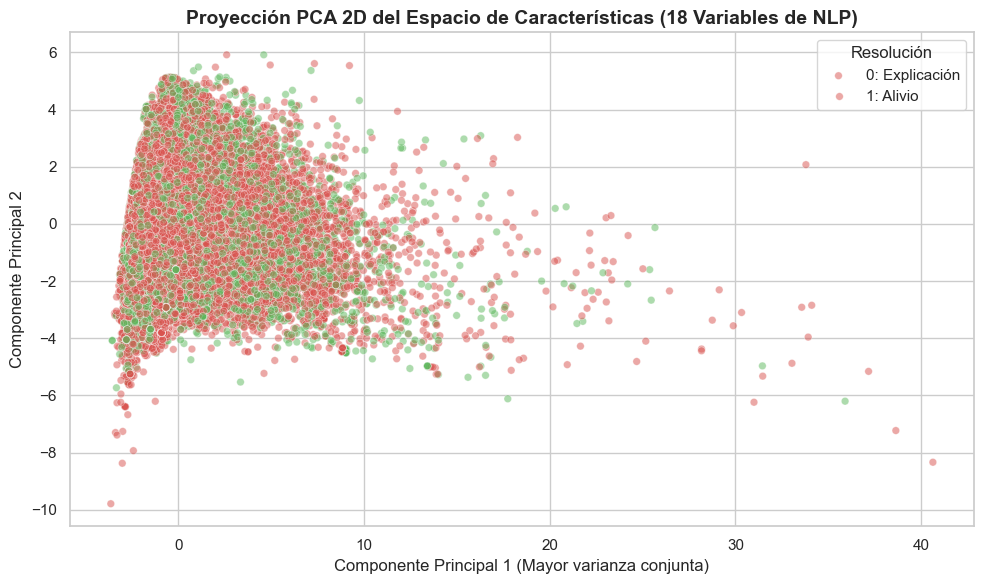

In [7]:
# 4. COMPRESIÓN DEL ESPACIO MULTIDIMENSIONAL (PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA para reducir de 18 variables a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame temporal para la gráfica
df_pca = pd.DataFrame(data=X_pca, columns=['Componente_Principal_1', 'Componente_Principal_2'])
df_pca['Target'] = y.values

# Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, 
    x='Componente_Principal_1', 
    y='Componente_Principal_2', 
    hue='Target', 
    palette={0: '#d9534f', 1: '#5cb85c'},
    alpha=0.5,
    s=30
)

plt.title('Proyección PCA 2D del Espacio de Características (18 Variables de NLP)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1 (Mayor varianza conjunta)')
plt.ylabel('Componente Principal 2')
plt.legend(title='Resolución', labels=['0: Explicación', '1: Alivio'])

plt.tight_layout()
plt.show()


***Conclusión Técnica del EDA:** La proyección PCA confirma que las clases comparten el mismo espacio de características. Un hiperplano lineal fallará en separar las clases eficientemente. Se requiere un modelo capaz de mapear estos datos a una dimensión superior para encontrar patrones curvos o circulares, tarea en la que el Kernel RBF de Support Vector Machines destaca.*